In [ ]:
%matplotlib inline

In [ ]:
import numpy as np
import h5py
from matplotlib import pyplot as plt
import sklearn as sk

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm import tqdm
from astropy.visualization import SimpleNorm
from matplotlib.colors import Normalize


In [ ]:
# reproducibility
torch.manual_seed(0)
np.random.seed(0)

# use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [ ]:
CLASS_NAMES = [
'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge']
with h5py.File('Galaxy10_DECals_64x64.h5') as F:
    images = np.array(F['images'])
     # shape (17736, 64, 64, 3)
    labels = np.array(F['ans'])


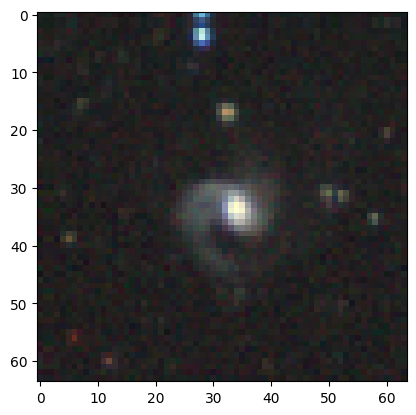

In [ ]:
plt.imshow(images[108])

## Task 1 – Exploration and preprocessing.

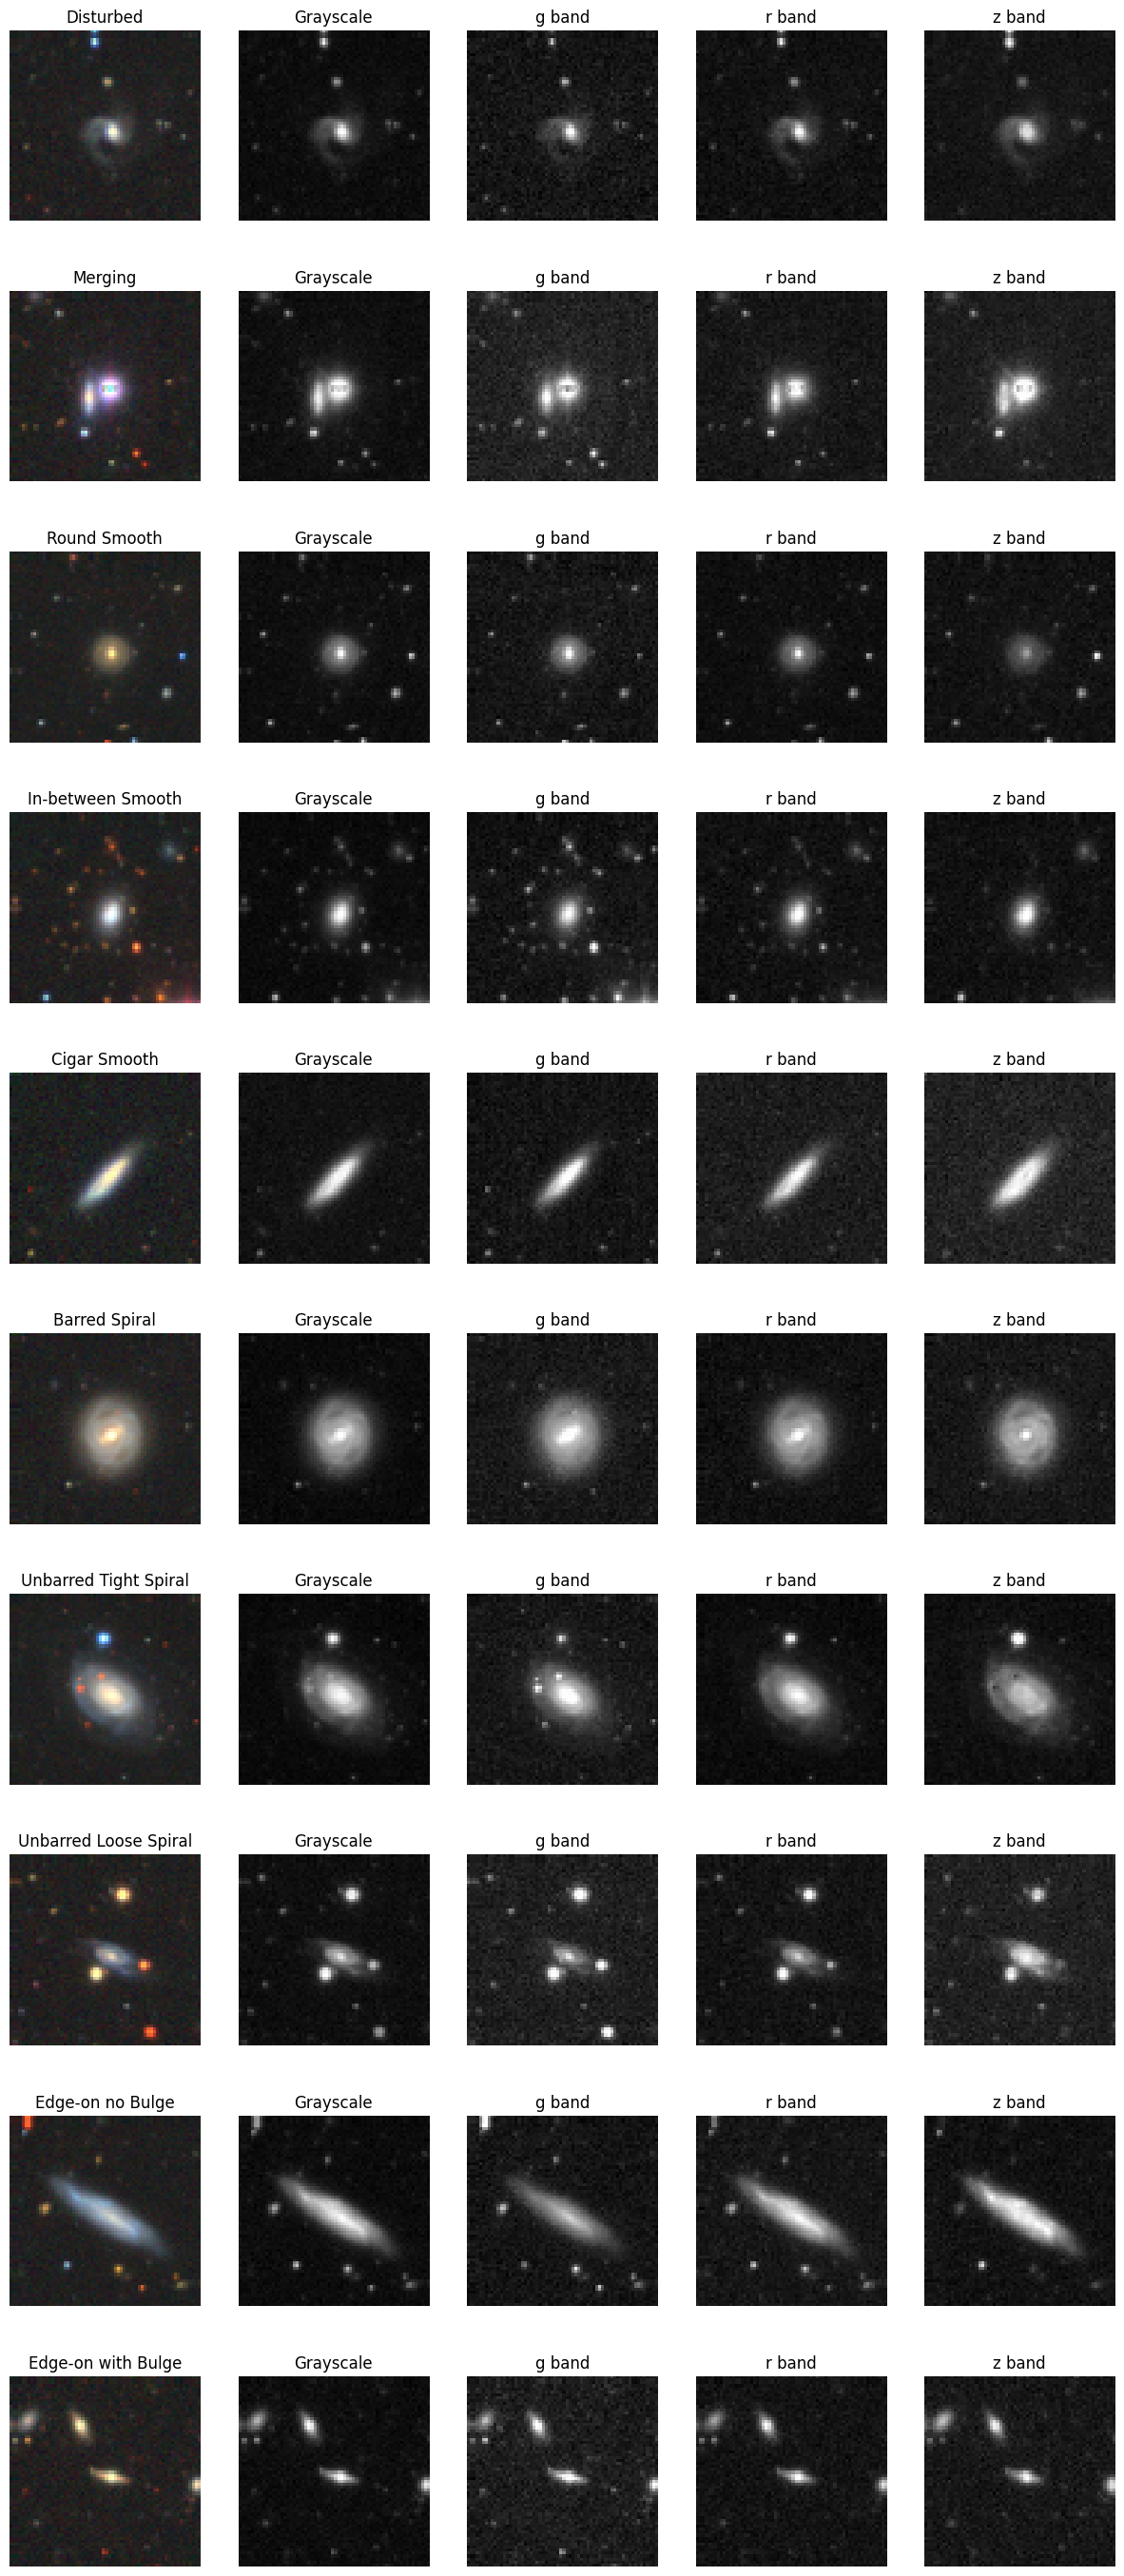

In [ ]:
#average over the last array dimension (color channels) to grayscale
images_gs = images.mean(axis=-1)
n_gal = 108
fig, ax = plt.subplots(len(CLASS_NAMES), 5, figsize=(15, 35))
for i, classname in enumerate(CLASS_NAMES):
    ax[i, 0].imshow(images[labels == i][n_gal])
    ax[i, 0].set_title(classname)
    ax[i, 0].axis('off')
    ax[i, 1].imshow(images_gs[labels == i][n_gal], cmap='gray')
    ax[i, 1].axis('off')
    ax[i, 1].set_title(f'Grayscale')
    ax[i, 2].imshow(images[labels == i][n_gal][:,:,0], cmap='gray')
    ax[i, 2].axis('off')
    ax[i, 2].set_title(f'g band')
    ax[i, 3].imshow(images[labels == i][n_gal][:,:,1], cmap='gray')
    ax[i, 3].axis('off')
    ax[i, 3].set_title(f'r band')
    ax[i, 4].imshow(images[labels == i][n_gal][:,:,2], cmap='gray')
    ax[i, 4].axis('off')
    ax[i, 4].set_title(f'z band')

## Task 2 – SVD of a single image

In [ ]:
img = images_gs[n_gal]

In [ ]:
U, S, Vt = np.linalg.svd(img, full_matrices=False)

def reconstruct(U, S, Vt, r):
  '''
  Reconstruct the original matrix from the rank truncated SVD
  Args:
    U (ndarray): left singular vectors
    S (ndarray): singular values descending order
    Vt(ndarray): right singular vectors
    r (int): rank for the truncated reconstruction

  Returns:
    ndarray: reconstructed matrix from the first r components

  '''
  U_r = U[:,:r]
  S_r = np.diag(S[:r])
  Vt_r = Vt[:r, :]
  return U_r @ S_r @ Vt_r

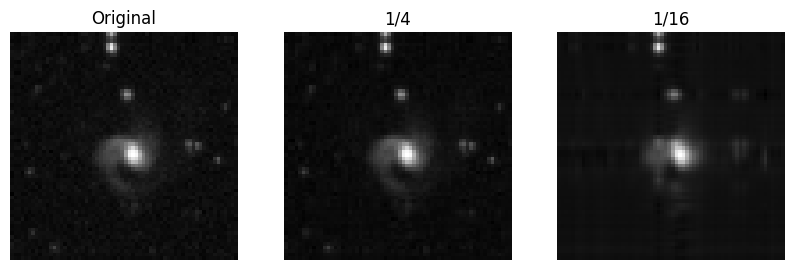

In [ ]:
#reconstruct for the 1/4 largest singular values (or rank 16 as 16/64=1/4)
img_4 = reconstruct(U, S, Vt, 16)
#reconstruct for the 1/6
img_16 = reconstruct(U, S, Vt, 4)

#plot reconstructions with the original
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img, cmap='gray')
axes[1].imshow(img_4, cmap='gray')
axes[2].imshow(img_16, cmap='gray')
axes[0].set_title('Original')
axes[1].set_title('1/4')
axes[2].set_title('1/16')
for ax in axes:
  ax.axis('off')

In [ ]:
fve = np.cumsum(S**2) / np.sum(S**2)
# "In case of multiple occurrences of the maximum values, the indices corresponding to the first occurrence are returned."
#- since we have only False and True values, argmax will return the first occurence of the True value.
r90 = np.argmax(fve>= 0.90) + 1
r99 = np.argmax(fve>= 0.99) + 1

print(r90)
print(r99)

2
5


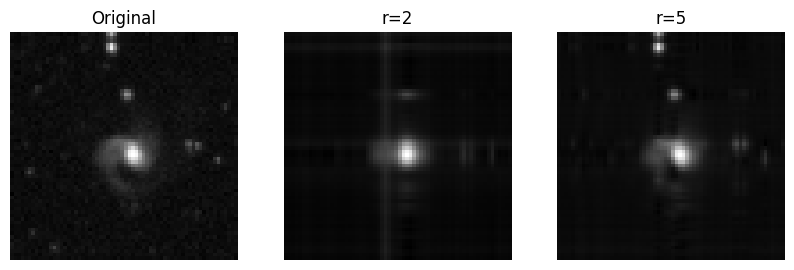

In [ ]:
#reconstruction for the ranks from FVE
img_90p = reconstruct(U, S, Vt, 2)
img_99p = reconstruct(U, S, Vt, 5)

fig, aimges = plt.subplots(1, 3, figsize=(10, 3))
aimges[0].imshow(img, cmap='gray')
aimges[1].imshow(img_90p, cmap='gray')
aimges[2].imshow(img_99p, cmap='gray')
aimges[0].set_title('Original')
aimges[1].set_title(f'r={r90}')
aimges[2].set_title(f'r={r99}')
for ax in aimges:
  ax.axis('off')

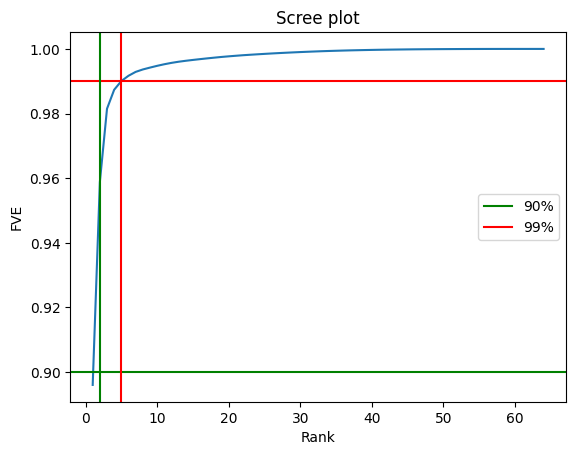

In [ ]:
plt.plot(np.arange(1,len(fve)+1), fve)
plt.axhline(0.90, color='g', label=f'90%')
plt.axhline(0.99, color='r', label=f'99%')
plt.axvline(r90, color='g')
plt.axvline(r99, color='r')
plt.xlabel('Rank')
plt.ylabel('FVE')
plt.title('Scree plot')
#plt.loglog()
plt.legend()

In [ ]:
beta =1 #square image can also be n, m = img.shape; beta = min(n,m) / max(n,m)
omega = 0.56*beta**3 - 0.95*beta**2 + 1.82*beta + 1.43
tau = omega * np.median(S)
r_thr = int(np.sum(S > tau))
print(r_thr)
print(fve[r_thr])


(64, 64)
8


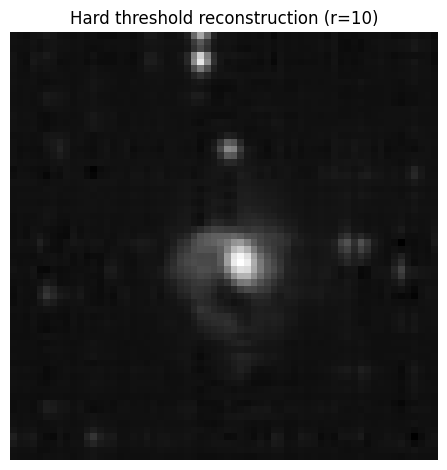

In [ ]:
img_thr = reconstruct(U, S, Vt, r_thr)
plt.figure()
plt.imshow(img_thr, cmap='gray')
plt.title(r'Hard threshold reconstruction (r=10)')
plt.axis('off')
plt.tight_layout()

## Task 3 – SVD over the full galaxy sample

In [ ]:
N = images_gs.shape[0] #shape 17736
full_ds = images_gs.reshape(N,-1).T # shape (4096,17736)
xmean = full_ds.mean(axis=1, keepdims=True) #mean along image axis
full_ds_centrd = full_ds - xmean
U_full, S_full, Vt_full = sk.utils.extmath.randomized_svd(full_ds_centrd, n_components = 4096)

In [ ]:
fve_all = np.cumsum(S_full**2) / np.sum(S_full**2)
r90_all = np.argmax(fve_all >= 0.90) + 1
r99_all = np.argmax(fve_all >= 0.99) + 1

print(fve_all)
print(r90_all)
print(r99_all)

[0.31767715 0.37228043 0.42425883 ... 0.99999986 0.99999998 1.        ]
329
2387


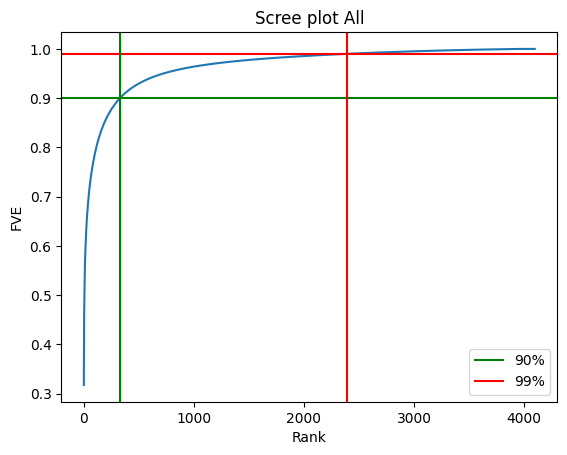

In [ ]:
plt.plot(np.arange(1,len(fve_all)+1), fve_all)
plt.axhline(0.90, color='g', label=f'90%')
plt.axhline(0.99, color='r', label=f'99%')
plt.axvline(r90_all, color='g')
plt.axvline(r99_all, color='r')
plt.xlabel('Rank')
plt.ylabel('FVE')
plt.title('Scree plot All')
plt.legend()

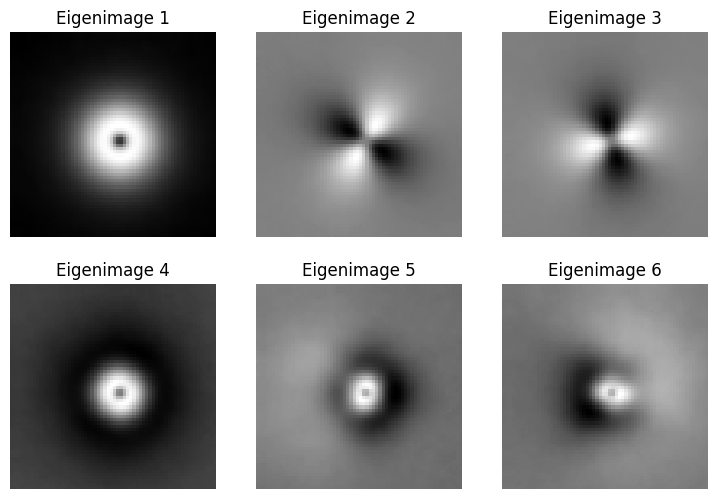

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for i, ax in enumerate(axes.flat):
  #Extract the i-th left singular vector
  eigen = U_full[:,i].reshape(64,64) #back to a 64x64 image
  ax.imshow(eigen, cmap='gray')
  ax.set_title(f'Eigenimage {i+1}')
  ax.axis('off')

In [ ]:
pca = (full_ds_centrd).T @ U_full[:,:]
pc1 = pca[:,0]
pc2 = pca[:,1]
# pc1 = S_full[0] * Vt_full[0, :]
# pc2 = S_full[1] * Vt_full[1, :]

In [ ]:
def pca_plot(pca_matrix, n1, n2, labels):
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(pca_matrix[:,n1], pca_matrix[:,n2], c=labels, cmap='tab10', s=0.5, alpha=0.6)
    cbar = fig.colorbar(scatter, label='Morphological class')
    cbar.set_ticks(np.arange(0, 10), labels=CLASS_NAMES)
    ax.set_xlabel(f'PC {n1+1}')
    ax.set_ylabel(f'PC {n2+1}')
    ax.set_title('Galaxy morphology in PCA space')

In [ ]:
def pca_plot_3d(pca_matrix, n1, n2, n3, labels):
    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(projection='3d')
    scatter = ax.scatter(pca_matrix[:,n1], pca_matrix[:,n2], pca_matrix[:,n3], c=labels, cmap='tab10', s=0.5, alpha=0.6)
    cbar = fig.colorbar(scatter, label='Morphological class')
    cbar.set_ticks(np.arange(0, 10), labels=CLASS_NAMES)
    ax.set_xlabel(f'PC {n1+1}')
    ax.set_ylabel(f'PC {n2+1}')
    ax.set_zlabel(f'PC {n3+1}')
    ax.set_title('Galaxy morphology in PCA space')

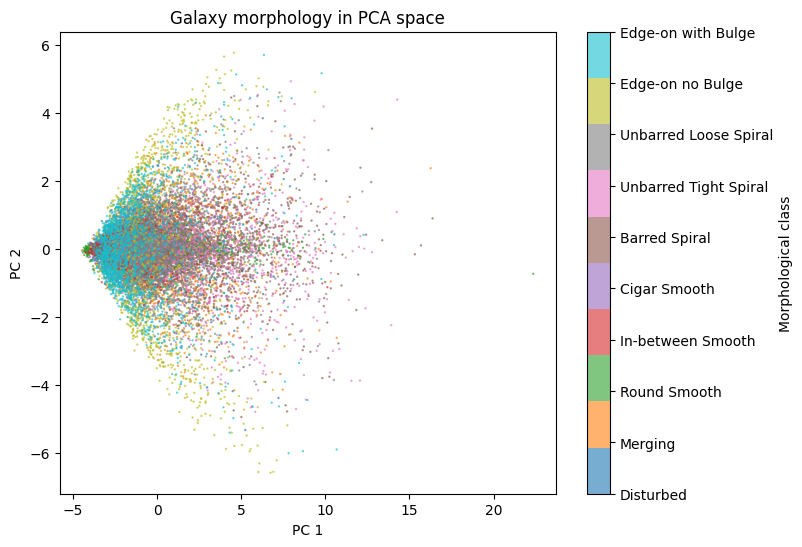

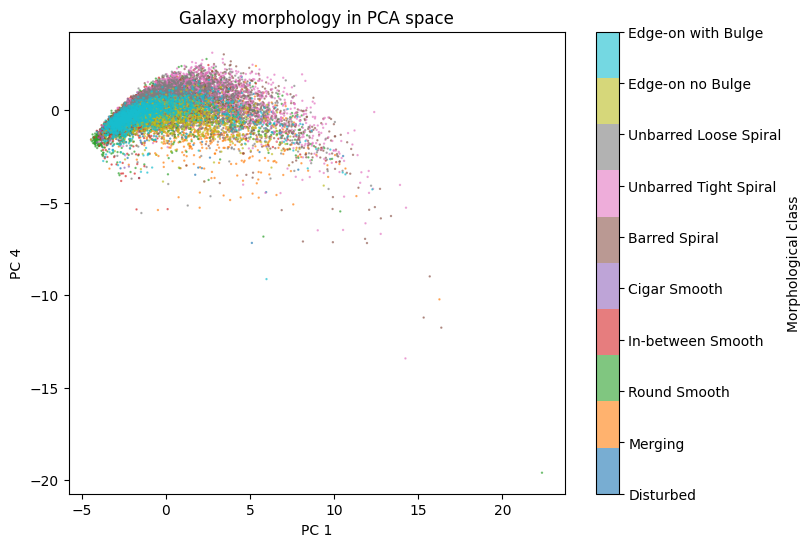

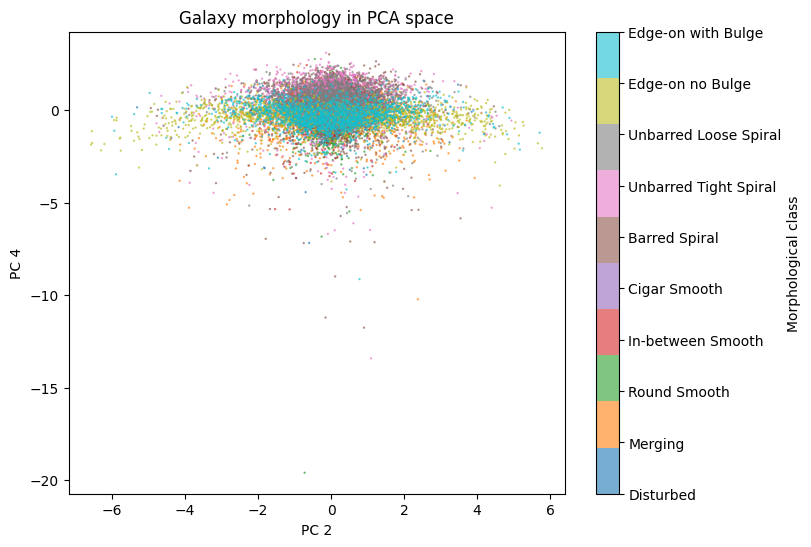

In [ ]:
pca_plot(pca, 0, 1, labels)
pca_plot(pca, 0, 3, labels)
pca_plot(pca, 1, 3, labels)

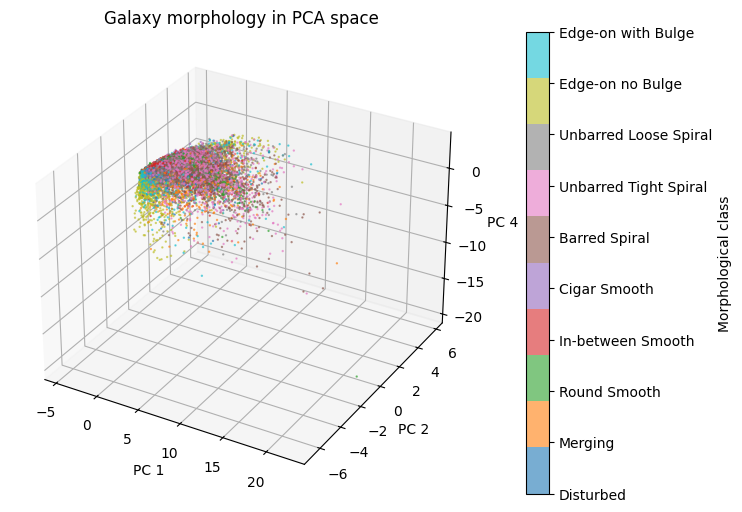

In [ ]:
pca_plot_3d(pca, 0, 1, 3, labels)

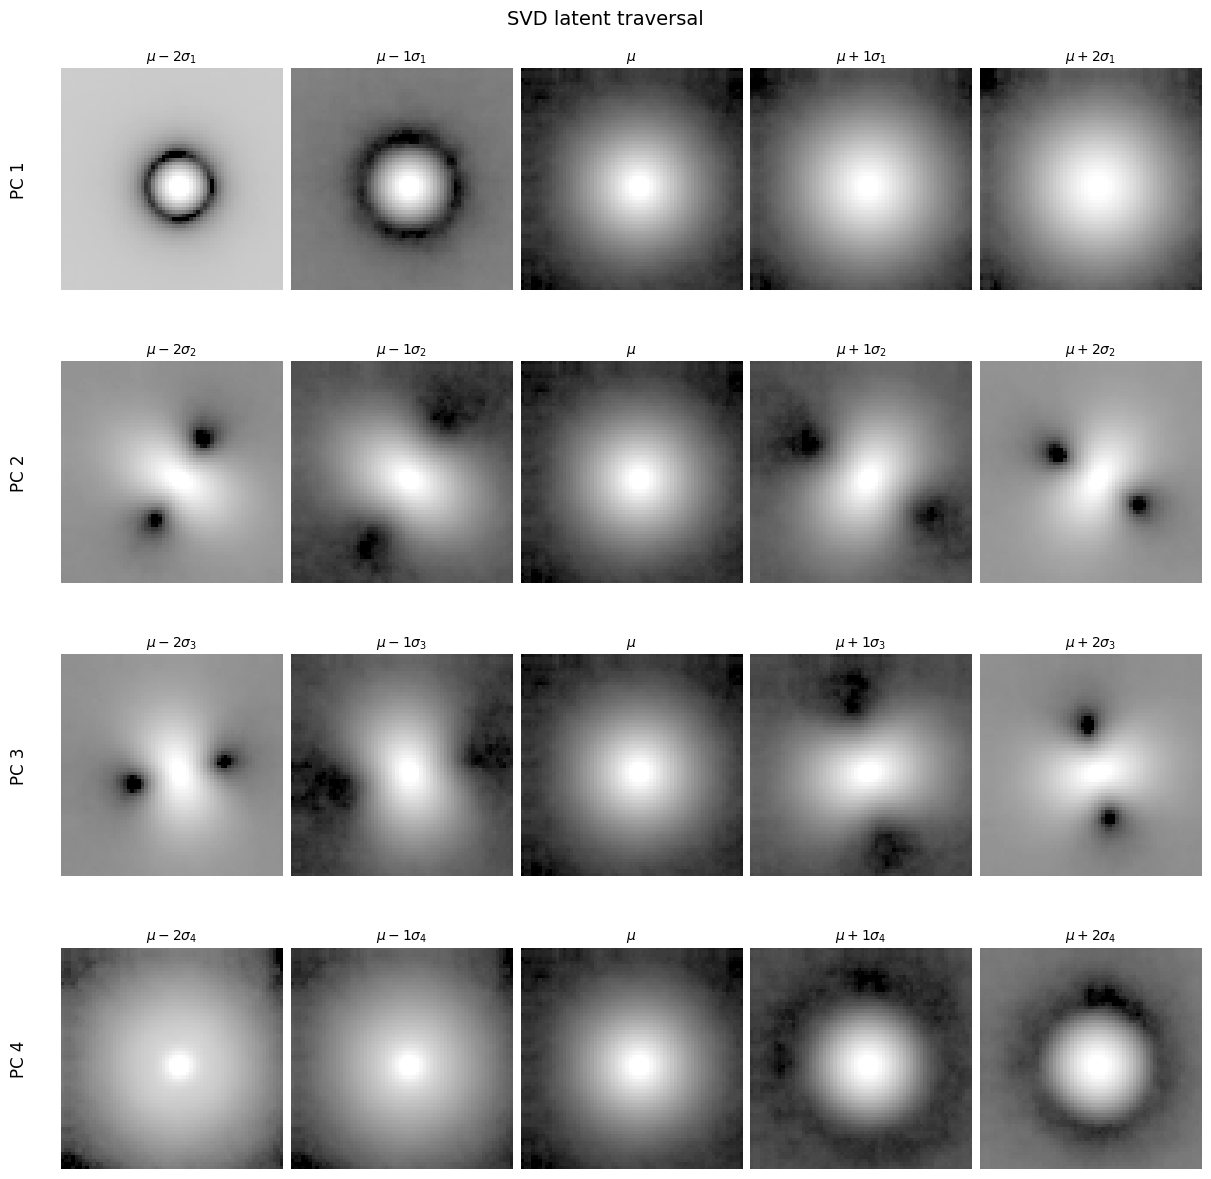

In [ ]:
n_pc = 4
n_sigms = 2

# Compute a standard deviation per PC
std = np.array([S_full[k] * Vt_full[k, :].std() for k in range(n_pc)])

fig, axes = plt.subplots(n_pc, 2*n_sigms+1,
                         figsize=(12, 3*n_pc),
                         constrained_layout=True)

for pc in range(n_pc):
    for j, i in enumerate(np.arange(-n_sigms, n_sigms+1, 1)):
        #Build displacement vector: move i std devs
        zj = np.zeros(n_pc)
        zj[pc] = i * std[pc]

        #Reconstruct image from mean + PC displacement
        x_h = xmean.ravel() + U_full[:, :n_pc] @ zj
        x_im = x_h.reshape(64, 64)

        snorm = SimpleNorm('log', percent=99)
        norm = snorm(x_im)

        axes[pc, j].imshow(x_im, cmap='gray', norm=norm)
        axes[pc, j].axis('off')

        if i == 0:
            axes[pc, j].set_title(r'$\mu$', fontsize=10)
        elif i > 0:
            axes[pc, j].set_title(rf'$\mu + {int(i)}\sigma_{{{pc+1}}}$', fontsize=10)
        else:
            axes[pc, j].set_title(rf'$\mu - {int(abs(i))}\sigma_{{{pc+1}}}$', fontsize=10)

    #Row label for each PC
    axes[pc, 0].text(-0.15, 0.5, f'PC {pc+1}',
                     transform=axes[pc, 0].transAxes,
                     fontsize=12, va='center', ha='right', rotation=90)

fig.suptitle('SVD latent traversal', fontsize=14)
plt.show()

## Task 4 – Convolutional autoencoder: training and reconstruction

First, let's look again at the shape and values range of our dataset:

In [ ]:
print('Loaded:', images_gs.shape, '  dtype:', images_gs.dtype)
print('Pixel range: [{:.3f}, {:.3f}]'.format(images_gs.min(), images_gs.max()))

Loaded: (17736, 64, 64)   dtype: float64
Pixel range: [0.029, 1.000]


Since the data in the initial dataset is sorted according to galaxy class, we need to choose the validation dataset randomly.

In [ ]:
def select_random_subset_indices(n: int, n_total: int):
    """
    Selects a random subset of indices from a total set of indices.

    This function generates two complementary sets of indices by randomly sampling
    a subset of a specified size from the total indices. The first set contains the
    remaining indices from the total set after sampling, and the second set contains
    the randomly selected indices.

    :param n: The size of the subset to be randomly selected.
    :param n_total: The total number of indices in the dataset.
    :return: A tuple of two numpy arrays - the first containing the indices left
             after the selection, and the second containing the randomly
             selected indices.
    """
    set1 = np.arange(n_total)
    set2 = np.sort(np.random.choice(set1, size=n, replace=False))
    set1 = np.setdiff1d(set1, set2)
    return set1, set2

We will use 90% of our dataset for trainig and 10% for validation

In [ ]:
N_DATA = len(images_gs)
N_TRAIN = int(0.9 * N_DATA)
N_VAL = N_DATA - N_TRAIN
BATCH_SIZE = 16

i_train, i_val = select_random_subset_indices(N_VAL, N_DATA)

# add channel dim: (N, 1, 64, 64)
x_train = torch.tensor(images_gs[i_train][:, None, :, :], dtype=torch.float32)
x_val   = torch.tensor(images_gs[i_val][:, None, :, :], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train, x_train),   # input == target (autoencoder)
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training images:   {x_train.shape}')
print(f'Validation images: {x_val.shape}')

Training images:   torch.Size([15962, 1, 64, 64])
Validation images: torch.Size([1774, 1, 64, 64])


We use the ConvAutoencoder class from the example notebook, it mirrors the one from the lecture notes.

In [ ]:
class ConvAutoencoder(nn.Module):
    """Convolutional autoencoder for square single-channel images."""

    def __init__(self, channels: int, size: int, latent_dim: int = 4):
        """
        Parameters
        ----------
        channels  : number of input channels (1 for grayscale)
        size      : spatial size of the input image (must be divisible by 8)
        latent_dim: dimension of the bottleneck (latent space)
        """
        super().__init__()
        assert size % 8 == 0, 'image size must be divisible by 8'
        self.latent_dim = latent_dim
        s = size // 8  # spatial size after 3 stride-2 convolutions
        self.s = s
        flat = 128 * s * s  # number of features before the bottleneck Dense

        # --- Encoder ---
        self.enc_conv = nn.Sequential(
            nn.Conv2d(channels, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.enc_fc = nn.Linear(flat, latent_dim)

        # --- Decoder ---
        self.dec_fc = nn.Linear(latent_dim, flat)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.Conv2d(32, channels, 3, stride=1, padding=1),
            nn.Sigmoid(),  # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to latent vectors."""
        h = self.enc_conv(x)  # (N, 128, s, s)
        h = h.view(h.size(0), -1)  # (N, 128*s*s)  flatten
        return self.enc_fc(h)  # (N, latent_dim)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Map latent vectors back to images."""
        h = self.dec_fc(z)  # (N, 128*s*s)
        h = h.view(h.size(0), 128, self.s, self.s)  # (N, 128, s, s)  reshape
        return self.dec_conv(h)  # (N, channels, H, W)N_TRAIN    = int(0.9*len(images))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))

Now we create an object of this class. We set number of dimensions of latent space to 4, size of square image (number of pixel in one side) to 64 and number of chanels (colors) to 1, since we work with grayscale images.

In [ ]:
LATENT_DIM = 4
SIZE       = 64
CHANNELS   = 1

model = ConvAutoencoder(channels=CHANNELS, size=SIZE, latent_dim=LATENT_DIM).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
print(model)

Total trainable parameters: 406,533
ConvAutoencoder(
  (enc_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (enc_fc): Linear(in_features=8192, out_features=4, bias=True)
  (dec_fc): Linear(in_features=4, out_features=8192, bias=True)
  (dec_conv): Sequential(
    (0): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)


Now we start training our model.

In [ ]:
EPOCHS = 200

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x_val_dev = x_val.to(device)

train_losses = []
val_losses = []

for epoch in tqdm(range(1, EPOCHS + 1)):
    # --- training ---
    model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        # data augmentation: random horizontal / vertical flip of image to increase training data set
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[3])   # horizontal flip
        if torch.rand(1).item() > 0.5:
            x_batch = x_batch.flip(dims=[2])   # vertical flip

        optimizer.zero_grad()
        loss = loss_fn(model(x_batch), x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)

    epoch_loss /= N_TRAIN
    train_losses.append(epoch_loss)

    # --- validation ---
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(x_val_dev), x_val_dev).item()
    val_losses.append(val_loss)

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  train loss: {epoch_loss:.5f}  val loss: {val_loss:.5f}')

print('Training complete.')

 10%|█         | 20/200 [01:26<12:47,  4.27s/it]

Epoch  20/200  train loss: 0.00263  val loss: 0.00273


 20%|██        | 40/200 [02:51<11:25,  4.28s/it]

Epoch  40/200  train loss: 0.00255  val loss: 0.00269


 30%|███       | 60/200 [04:17<09:58,  4.28s/it]

...

Epoch 160/200  train loss: 0.00243  val loss: 0.00266


 90%|█████████ | 180/200 [13:45<01:39,  4.98s/it]

Epoch 180/200  train loss: 0.00242  val loss: 0.00266


100%|██████████| 200/200 [15:23<00:00,  4.62s/it]

Epoch 200/200  train loss: 0.00241  val loss: 0.00267
Training complete.


Now we plot the training curve

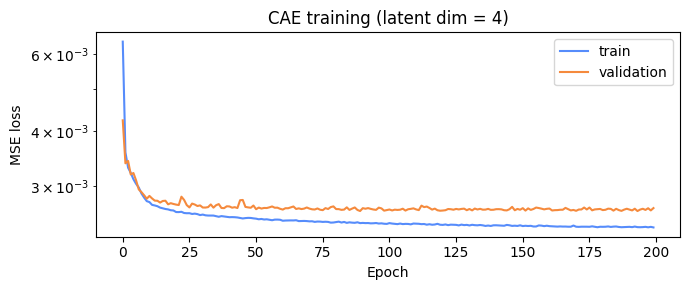

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(train_losses, label='train')
ax.plot(val_losses,   label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title(f'CAE training (latent dim = {LATENT_DIM})')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

We can clearly see that after a few tens of epochs the validation loss score almost doesn't change.

In [ ]:
# plot_idx = np.random.choice(len(x_val), N_SHOW, replace=False)

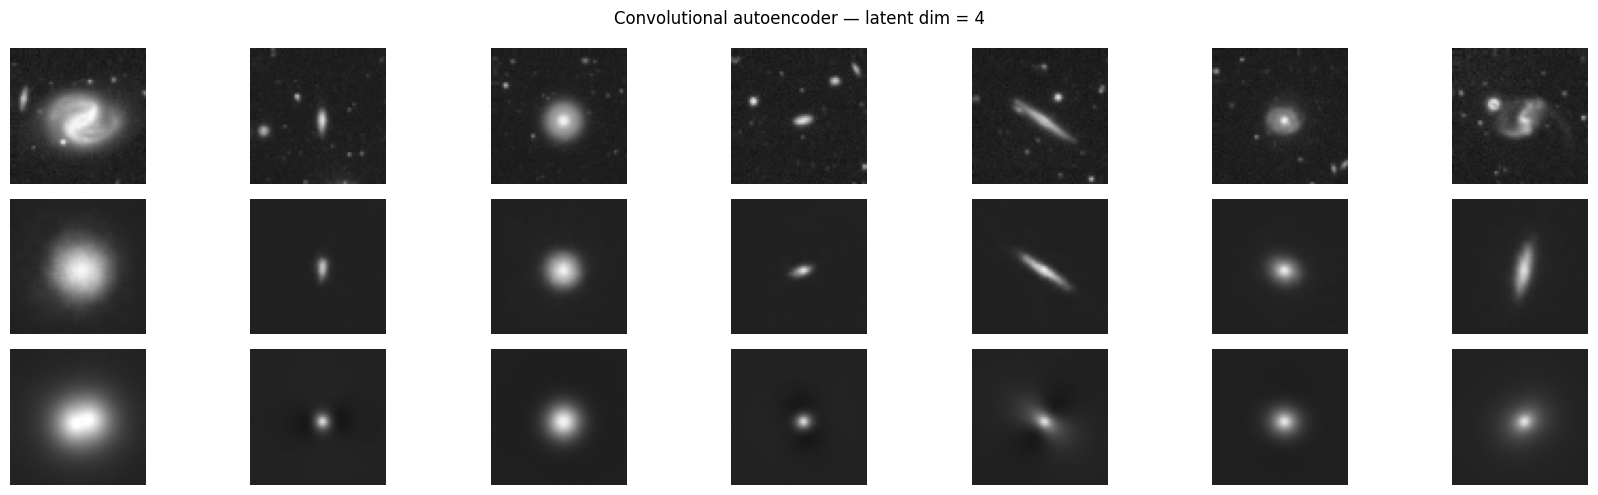

In [ ]:
N_SHOW = 7
plot_idx = [866, 749, 295, 532, 1531, 1061, 951]

model.eval()
with torch.no_grad():
    recons = model(x_val_dev[plot_idx]).cpu().numpy()   # (N_SHOW, 1, 64, 64)

originals = x_val[plot_idx].numpy()                     # (N_SHOW, 1, 64, 64)

recons_svd = reconstruct(U_full, S_full, Vt_full, 4) + xmean
recons_svd = recons_svd.T[i_val][plot_idx].reshape(len(plot_idx), 1, 64, 64)

fig, axes = plt.subplots(3, N_SHOW, figsize=(2.5 * N_SHOW, 5))

row_labels = ['Original', 'Reconstruction', 'SVD reconstruction']
for row, (imgs, label) in enumerate(zip([originals, recons, recons_svd], row_labels)):
    axes[row, 0].set_ylabel(label, fontsize=11)
    for col in range(N_SHOW):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.suptitle(f'Convolutional autoencoder — latent dim = {LATENT_DIM}', fontsize=12)
plt.tight_layout()
plt.show()

Now let's compare the MSE for CAE and SVD methods:

In [ ]:
def mean_squared_error(initial_data, reconstructed_data):
    return np.mean((initial_data-reconstructed_data)**2)

In [ ]:
model.eval()
with torch.no_grad():
    recons = model(x_val_dev).cpu().numpy()   # (N_SHOW, 1, 64, 64)

originals = x_val.numpy()                     # (N_SHOW, 1, 64, 64)

recons_svd = reconstruct(U_full, S_full, Vt_full, 4) + xmean
recons_svd = recons_svd.T[i_val].reshape(len(i_val), 1, 64, 64)

print(f'MSE for CAE: {mean_squared_error(originals, recons):.5f}')
print(f'MSE for SVD: {mean_squared_error(originals, recons_svd):.5f}')


MSE for CAE: 0.00267
MSE for SVD: 0.00294


## Task 5 – Latent space structure

First, we encode all of the images. Since the total number of images is big, we split in into batches and encode every batch separately.

In [ ]:
x_full = torch.tensor(images_gs[:, None, :, :], dtype=torch.float32)

dataset = TensorDataset(x_full)
dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

model.eval()
all_latent_vectors = []

with torch.no_grad():
    for batch in dataloader:
        batch_x = batch[0].to(device)
        latent_batch = model.encode(batch_x)
        all_latent_vectors.append(latent_batch.cpu().numpy())

lat_all = np.concatenate(all_latent_vectors, axis=0)

print(f"Shape of encoded latent vectors: {lat_all.shape}")
# Expected output: (17736, 4)

Shape of encoded latent vectors: (17736, 4)


Now we plot projection of our images onto different planes in the latent space.

In [ ]:
def lat_plot(lat_matrix, n1, n2, labels):
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(lat_matrix[:,n1], lat_matrix[:,n2], c=labels, cmap='tab10', s=0.5, alpha=0.6)
    cbar = fig.colorbar(scatter, label='Morphological class')
    cbar.set_ticks(np.arange(0, 10), labels=CLASS_NAMES)
    ax.set_xlabel(f'Latent coordinate {n1+1}')
    ax.set_ylabel(f'Latent coordinate {n2+1}')
    ax.set_title('Galaxy morphology in latent space')

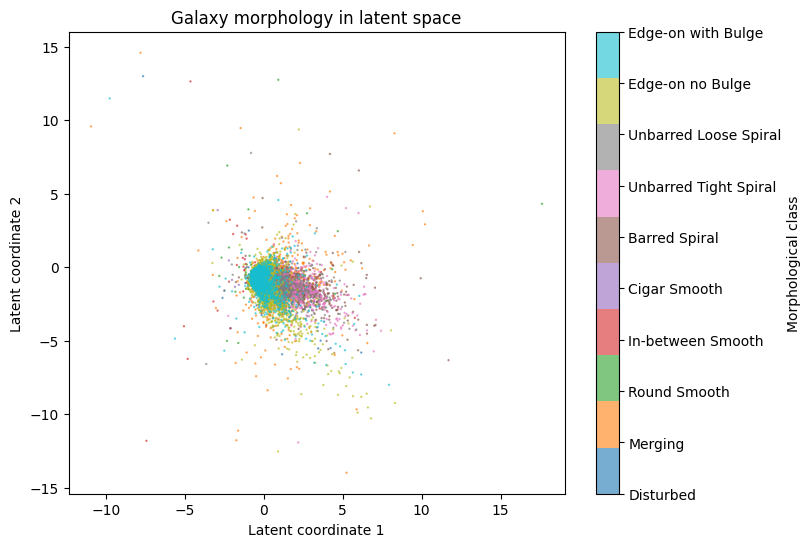

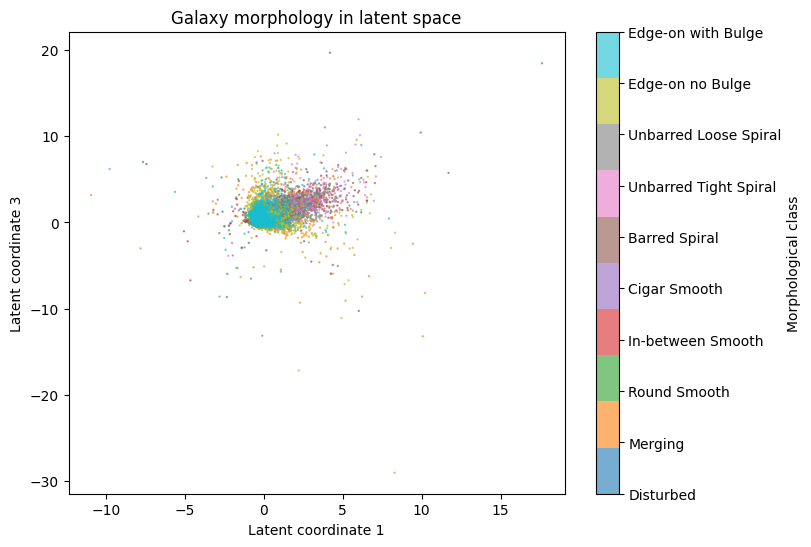

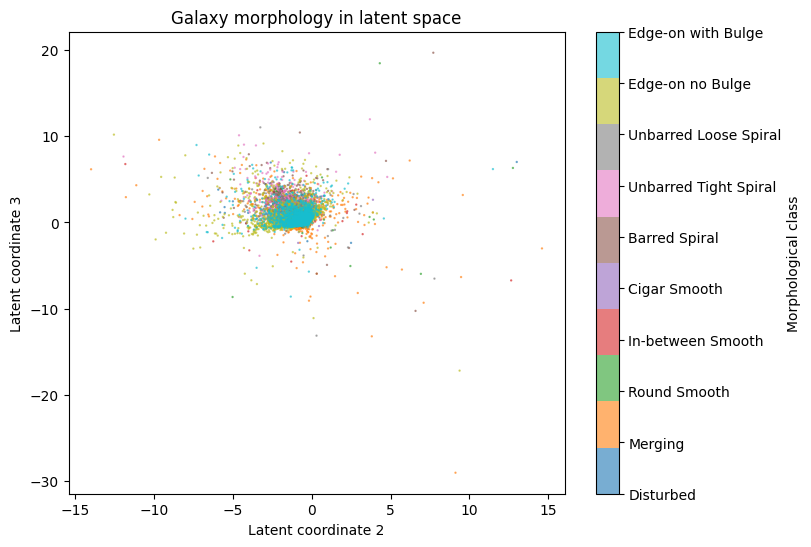

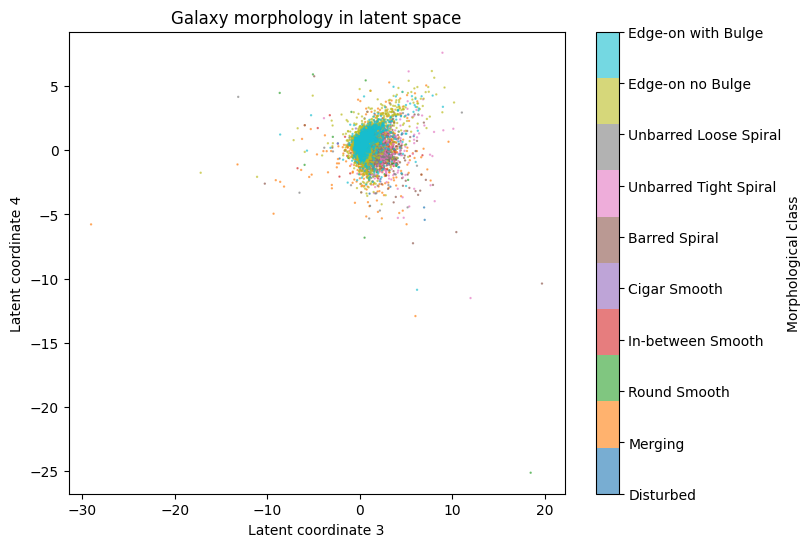

In [ ]:
lat_plot(lat_all, 0, 1, labels)
lat_plot(lat_all, 0, 2, labels)
lat_plot(lat_all, 1, 2, labels)
lat_plot(lat_all, 2, 3, labels)

For illustration purposes we also plot positions of our images in the latent space in 3D.

In [ ]:
def lat_plot_3d(lat_matrix, n1, n2, n3, labels):
    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(projection='3d')
    scatter = ax.scatter(lat_matrix[:,n1], lat_matrix[:,n2], lat_matrix[:,n3], c=labels, cmap='tab10', s=0.5, alpha=0.6)
    cbar = fig.colorbar(scatter, label='Morphological class')
    cbar.set_ticks(np.arange(0, 10), labels=CLASS_NAMES)
    ax.set_xlabel(f'Latent coordinate {n1+1}')
    ax.set_ylabel(f'Latent coordinate {n2+1}')
    ax.set_zlabel(f'Latent coordinate {n3+1}')
    ax.set_title('Galaxy morphology in latent space')

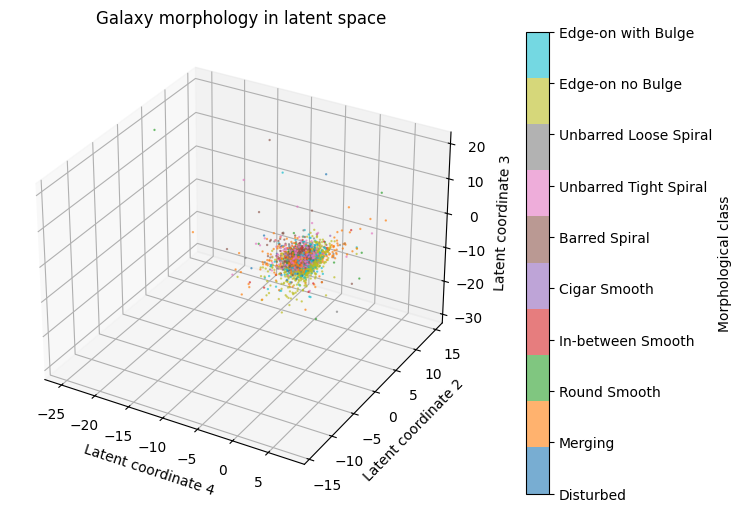

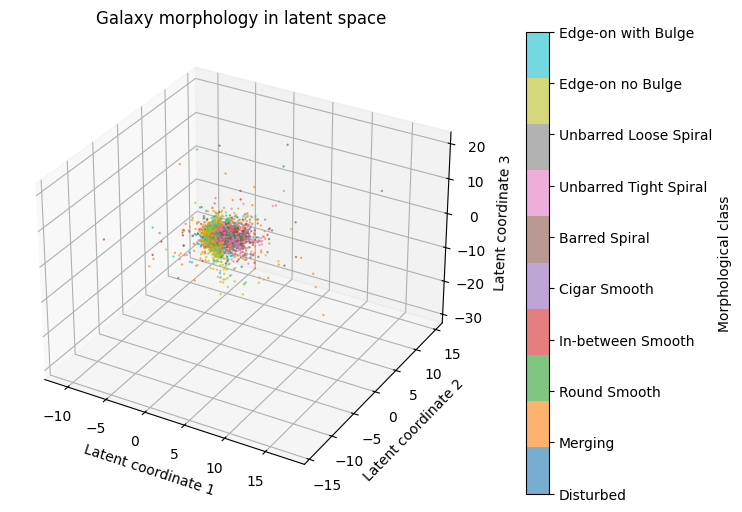

In [ ]:
lat_plot_3d(lat_all, 3, 1, 2, labels)
lat_plot_3d(lat_all, 0, 1, 2, labels)

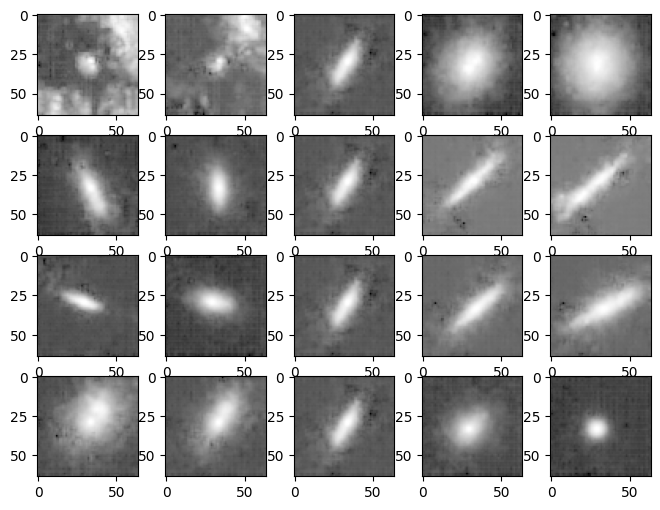

In [ ]:
lat_stds = np.std(lat_all, axis=0)

n_stds = 2
stds = np.arange(-n_stds, n_stds+1, 1)

fig, axes = plt.subplots(LATENT_DIM, len(stds), figsize=(8, 6))

model.eval()
for lat_c, lat_std in enumerate(lat_stds):
    lat_vec_std = np.zeros(LATENT_DIM)
    lat_vec_std[lat_c] = lat_std
    for i, std_c in enumerate(stds):
        lat_vec = lat_vec_std * std_c
        lat_vec = np.expand_dims(lat_vec, axis=0)
        lat_tensor = torch.tensor(lat_vec, dtype=torch.float32).to(device)

        with torch.no_grad():
            reconstructed_tensor = model.decode(lat_tensor)

        reconstructed_image = reconstructed_tensor.cpu().numpy()
        img_ = np.squeeze(reconstructed_image)

        snorm = SimpleNorm('log', percent=100)
        norm = snorm(img_)
        axes[lat_c][i].imshow(img_, cmap = 'gray', norm=norm)

## Task 6 – Latent space interpolation and comparison with SVD

We choose 2 distinct galaxies (first one is barred spiral, second one is edge-on with bulge)

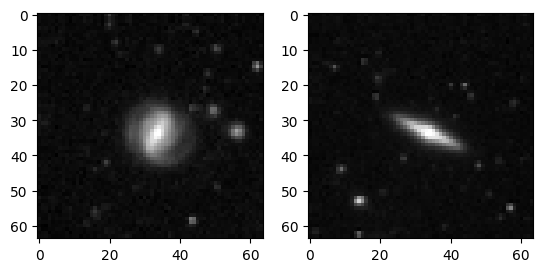

In [ ]:
l1 = 5; l2 = 9
n1 = 2; n2 = 1

gal1 = images_gs[labels==l1][n1]
gal2 = images_gs[labels==l2][n2]

fig, axes = plt.subplots(1, 2)
axes[0].imshow(gal1, cmap='gray')
axes[1].imshow(gal2, cmap='gray')

We want to investigate smooth transition from the vector representation of the first galaxy (in latent space for CAE and pc space for SVD) to the vector representation of the second galaxy. This transition can be achived by a linear interpolation with n_steps intermediate steps.

In [ ]:
def our_interpolation(vec1, vec2, n_steps=5):
    alph = np.linspace(0, 1, n_steps, endpoint=True).reshape(-1,1)
    interp_vec = (1-alph) * vec1 + alph * vec2
    return interp_vec

In [ ]:
n_steps = 5

First, we perform CAE interpolation.

In [ ]:
lat_vec_1 = lat_all[labels==l1][n1]
lat_vec_2 = lat_all[labels==l2][n2]

lat_vec_interp = our_interpolation(lat_vec_1, lat_vec_2, n_steps=n_steps)

model.eval()

lat_interp_tensor = torch.tensor(lat_vec_interp, dtype=torch.float32).to(device)

with torch.no_grad():
    reconstructed_tensor_interp = model.decode(lat_interp_tensor)

image_interp = reconstructed_tensor_interp.cpu().numpy()

image_interp = np.squeeze(image_interp)

Next we perform SVD interpolation.

In [ ]:
r = r90_all # r90_all is 329
pca_r90 = full_ds_centrd.T @ U_full[:,:r] # projection of all images on r90_all first principal components

pc_vec_1 = pca_r90[labels==l1][n1]
pc_vec_2 = pca_r90[labels==l2][n2]

pc_vec_interp = our_interpolation(pc_vec_1, pc_vec_2, n_steps=n_steps)

recons_svd_interp = (U_full[:,:r] @ pc_vec_interp.T + xmean).T

Now we plot CAE and SVD interpolations together.

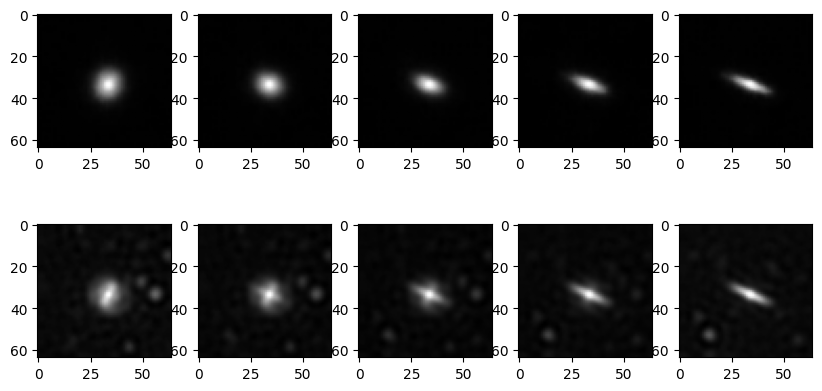

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(n_steps):
    axes[0,i].imshow(image_interp[i], cmap='gray')
    axes[1,i].imshow(recons_svd_interp[i].reshape(64,64), cmap='gray')